# Kinematics Analysis

Here the kinematics of the given globular clusters in the Milky Way will be analaysed. 

In [1]:
# Import libraries. Note: For me, cmasher keeps crashing the kernel so I have not used it thus far. However, I do not think it is necessary.

from math import log10, floor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colours
import cmasher as cm
from astropy.io import ascii, fits
from astropy.table import Table, join
from scipy.odr import *

C:\Users\troub\AppData\Local\Temp\ipykernel_6732\272712874.py:11: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import *


In [2]:
# Load data
data = pd.read_csv("../data/cleaned/globular_clusters_cleaned.csv")

In [13]:
# Confirm data is loaded correctly for Harris I
data.head()
data.columns

Index(['FeH', 'Age', 'Age_err', 'Method', 'Figs', 'Range', 'HBtype', 'R_G',
       'M_V', 'v_e0', 'log_sigma_0', 'Cluster_ID', 'RA', 'DEC', 'L', 'B',
       'R_Sun', 'R_gc', 'X', 'Y', 'Z', 'v_r', 'v_r_e', 'v_LSR', 'sig_v',
       'sig_v_e', 'c', 'r_c', 'r_h', 'mu_V', 'rho_0', 'lg_tc', 'lg_th',
       'Mstar', 'rh', 'C5', 'Age_Krause', 'FeH_Krause'],
      dtype='str')

In [14]:
# Check for missing values in the datasets
data.isna().sum()

FeH             0
Age             0
Age_err         0
Method          0
Figs            0
Range          22
HBtype          0
R_G             0
M_V             0
v_e0            0
log_sigma_0     0
Cluster_ID      0
RA              0
DEC             0
L               0
B               0
R_Sun           0
R_gc            0
X               0
Y               0
Z               0
v_r             0
v_r_e           0
v_LSR           0
sig_v          18
sig_v_e        18
c               0
r_c             0
r_h             0
mu_V            0
rho_0           0
lg_tc           0
lg_th           0
Mstar           3
rh              3
C5              3
Age_Krause      3
FeH_Krause      3
dtype: int64

Original Data labelling guide for Harris I.
- ID: Cluster identification number
- Name: Other commonly used cluster name
- RA,DEC: Right ascension and declination (epoch J2000)
- L,B: Galactic longitude and latitude (degrees)
- R_Sun: Distance from Sun (kiloparsecs)
- R_gc: Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- X,Y,Z: Galactic distance components X,Y,Z in kiloparsecs, in a
    Sun-centered coordinate system; X points toward Galactic center, 
    Y in direction of Galactic rotation, Z toward North Galactic Pole

Original Data labelling guide for Harris III.
- ID: Identifier of the globular cluster
- v_r: Radial velocity
- v_r_e: Uncertainty in the radial velocity
- v_LSR: Radial velocity corrected to the Local Standard of Rest (LSR)
- sig_v: Central velocity dispersion
- sig_v_e: Uncertainty in the central velocity dispersion.
- c: Concentration parameter (how dense the core is compared to its outer edge)
- r_c: Core radius
- r_h: Half-light radius
- mu_V: Central surface brightness in the V (visual) band
- rho_0: Central mass density
- lg_tc: Base-10 logarithm of the core relaxation time
- lg_th: Base-to logarithm of the half-mass relaxation time.

In [16]:
# Confirm the total number of clusters between all data sets align.
print(data["Cluster_ID"].nunique())

55


In [ ]:
# I haven't been running this cell thus far, but am hesitant to cut it out as I haven't yet decided if it will be useful in the future. Just keep in mind if you wish to use this data. You can skip this cell.
# Define variables from the Harris PI data.
L = data1['L']
B = data1['B']
X = data1['X']
Y = data1['Y']
Z = data1['Z']

# Define variables from the Harris PIII data.
v_r = data3['v_r']
v_r_e = data3['v_r_e']
sig_v = data3['sig_v']
sig_v_e = data3['sig_v_e']
c = data3['c']
r_h = data3['r_h']
rho_0 = data3['rho_0']
v_LSR = data3['v_LSR']

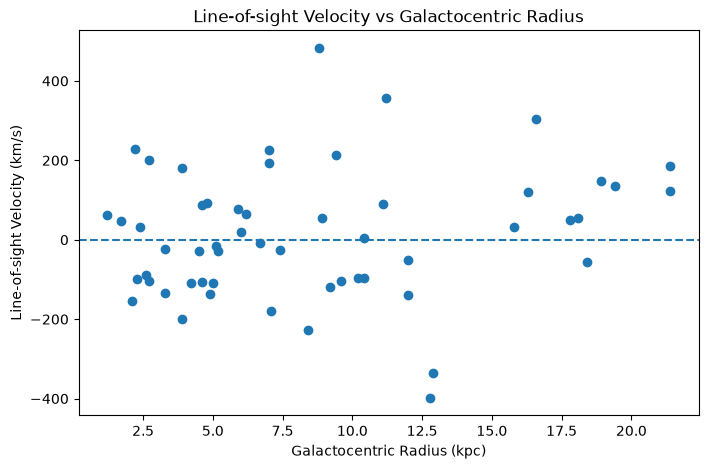

In [17]:
# Plot the line-of-sight velocity against the galactocentric radius.

plt.figure(figsize=(8,5))

plt.scatter(data["R_gc"], data["v_LSR"])   

plt.axhline(0, linestyle="--")

plt.xlabel("Galactocentric Radius (kpc)")
plt.ylabel("Line-of-sight Velocity (km/s)")
plt.title("Line-of-sight Velocity vs Galactocentric Radius")

plt.show()


Text(0, 0.5, 'Galactic Longitude, $degrees$')

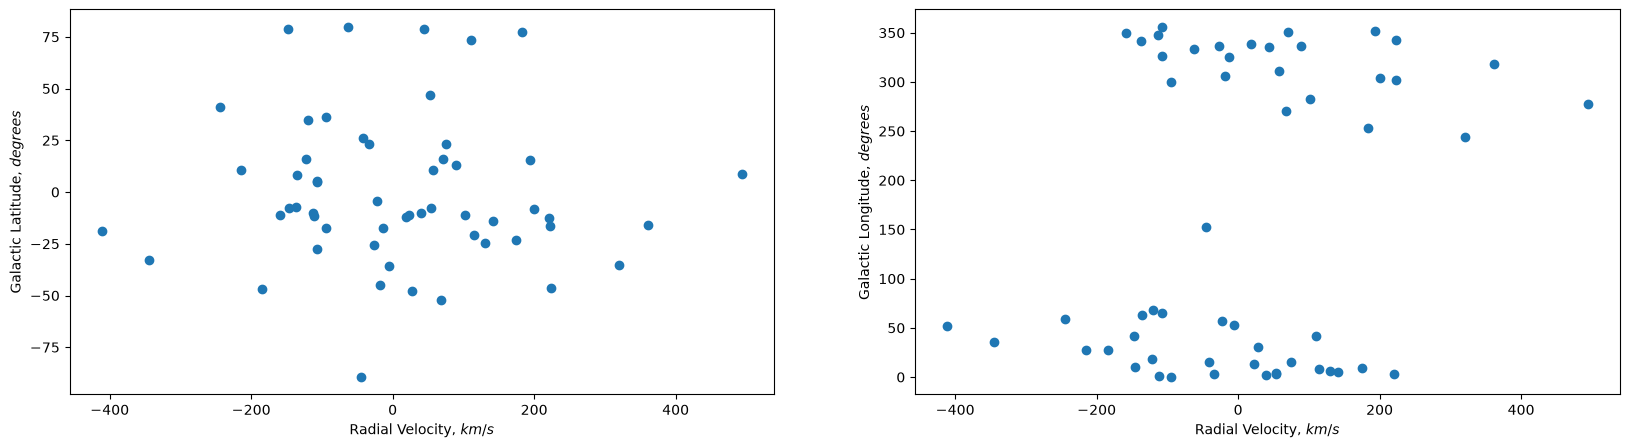

In [11]:
fig, axes = plt.subplots(1, 2,figsize=(20,5))

# Plot v_r against B
vb = axes[0].scatter(data["v_r"], data["B"]) # Plot components
axes[0].set_xlabel("Radial Velocity, $km/s$") # x-axis label
axes[0].set_ylabel("Galactic Latitude, $degrees$") # y-axis label

# Plot v_r against L
vl = axes[1].scatter(data["v_r"], data["L"]) # Plot components
axes[1].set_xlabel("Radial Velocity, $km/s$") # x-axis label
axes[1].set_ylabel("Galactic Longitude, $degrees$") # y-axis label

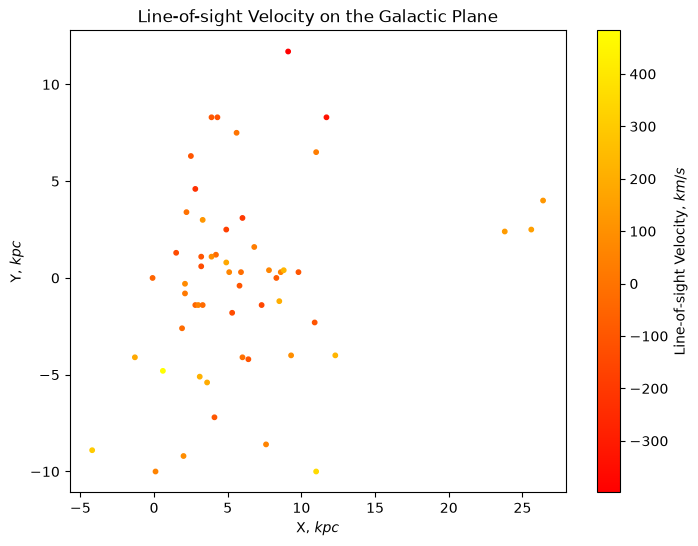

In [16]:
# X vs. Y coloured by V_LSR

plt.figure(figsize=(8,6))

plt.scatter(data["X"], data["Y"], c=data["v_LSR"], cmap='autumn', s=10)   

plt.xlabel("X, $kpc$")
plt.ylabel("Y, $kpc$")
plt.title("Line-of-sight Velocity on the Galactic Plane")

cbar = plt.colorbar()
cbar.set_label("Line-of-sight Velocity, $km/s$")

plt.show()
